<a href="https://colab.research.google.com/github/clarshine/matkul-visualisasi-data/blob/main/41823110038_CLARESTA_FRANSISKA_OKTIVIA_UAS_VISUALISASI_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UAS VISUALISASI DATA**

NIK : 41823110038

NAMA: CLARESTA FRANSISKA OKTIVIA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.  Time Series

In [ ]:
data1 = pd.read_csv('police.csv')

a. Menampilkan data

In [ ]:
data1.head()

,state,stop_date,stop_time,county_name,driver_gender,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,district
0,RI,2005-01-04,12:55,NaN,M,White,Equipment/Inspection Violation,Equipment,False,NaN,Citation,False,0-15 Min,False,Zone X4
1,RI,2005-01-23,23:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone K3
2,RI,2005-02-17,04:15,NaN,M,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X4
3,RI,2005-02-20,17:15,NaN,M,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False,Zone X1
4,RI,2005-02-24,01:20,NaN,F,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False,Zone X3


b. Melakukan pengecekan jenis kelamin mana yang paling banyak
melakukan pelanggaran lalu lintas

In [ ]:
proporsi = data1['driver_gender'].value_counts(normalize=True).rename("proportion")
print(proporsi)

driver_gender
M    0.724841
F    0.275159
Name: proportion, dtype: float64


c. Menampilkan potensi pelanggaran yang
banyak dilakukan oleh kedua jenis kelamin

In [ ]:
print(data1.groupby(['driver_gender', 'violation']).search_conducted.mean())

driver_gender  violation          
F              Equipment              0.103933
               Moving violation       0.058608
               Other                  0.059406
               Registration/plates    0.120755
               Speeding               0.009642
M              Equipment              0.104101
               Moving violation       0.080616
               Other                  0.079621
               Registration/plates    0.155772
               Speeding               0.030466
Name: search_conducted, dtype: float64


d. Membuat grafik yang menampilkan tingkat penangkapan yang
dilakukan oleh pihak kepolisian

In [ ]:
combined = data1.stop_date.str.cat(data1.stop_time, sep=' ')

data1['stop_datetime'] = pd.to_datetime(combined)
data1['is_arrested'] = data1['is_arrested'].astype(bool)

data1.set_index('stop_datetime', inplace=True)

hourly_arrest_rate = data1.groupby(data1.index.hour).is_arrested.mean()

Text(0.5, 1.0, 'Arrest Rate by Time of Day')

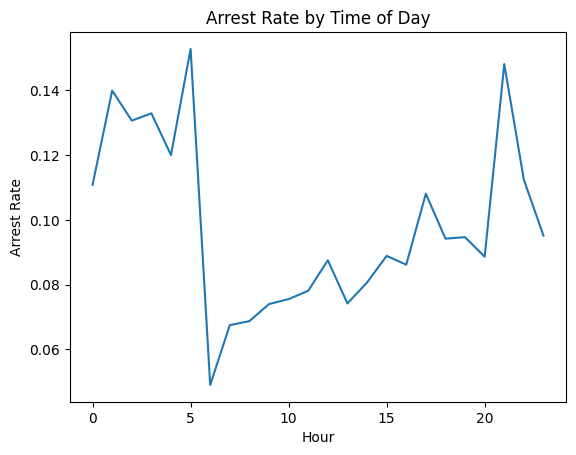

In [ ]:
import matplotlib.pyplot as plt

hourly_arrest_rate.plot()

plt.xlabel('Hour')
plt.ylabel('Arrest Rate')
plt.title('Arrest Rate by Time of Day')

e. Menampilkan data penangkapan karena keterkaitannya dengan
penangkapan narkoba

/tmp/ipython-input-46-3130632257.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_drug_rate = data1.drugs_related_stop.resample('A').mean()


<Axes: xlabel='stop_datetime'>

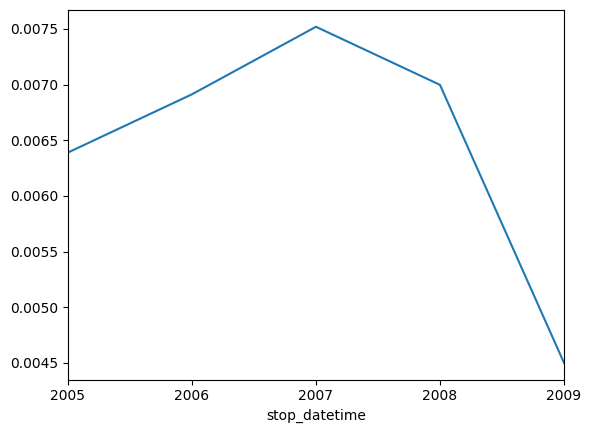

In [ ]:
annual_drug_rate = data1.drugs_related_stop.resample('A').mean()

annual_drug_rate.plot()

f. Menampilkan data yang menunjukan pemberhentian kendaraan
dengan keterkaitannya dengan penangkapan narkoba

/tmp/ipython-input-48-340662124.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_search_rate = data1.search_conducted.resample('A').mean()


array([<Axes: xlabel='stop_datetime'>, <Axes: xlabel='stop_datetime'>],
      dtype=object)

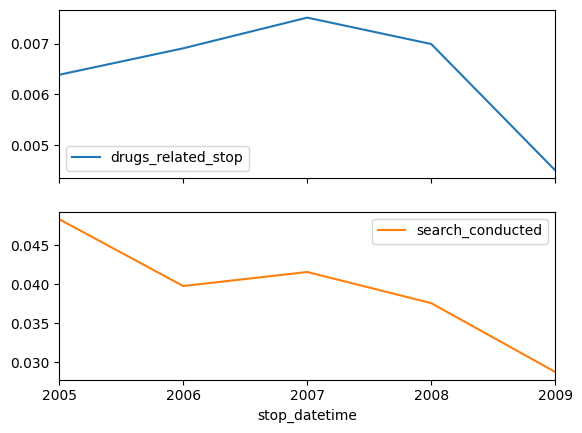

In [ ]:
annual_search_rate = data1.search_conducted.resample('A').mean()

annual = pd.concat([annual_drug_rate, annual_search_rate], axis='columns')

annual.plot(subplots=True)

g. Menampilkan grafik batang yang menunjukan pelanggaran yang
berhubungan dengan distrik pengendara

In [ ]:
all_zones = pd.crosstab(data1.district, data1.violation)

k_zones = all_zones.loc['Zone K1':'Zone K3']

<Axes: xlabel='district'>

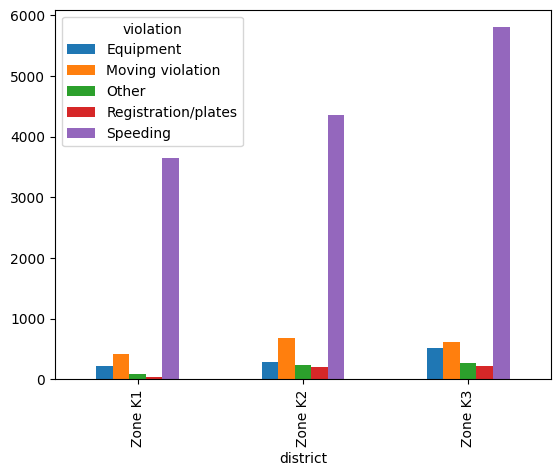

In [ ]:
k_zones.plot(kind='bar')

h. Menampilkan grafik batang yang menampilkan hubungan distrik dari
pengendara dengan pelanggaran yang dilakukan

<Axes: xlabel='district'>

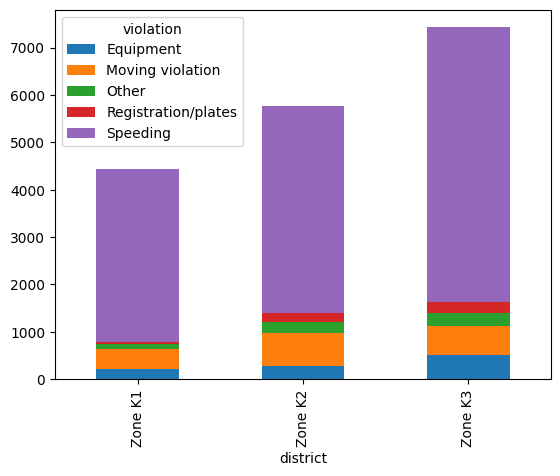

In [ ]:
k_zones.plot(kind='bar', stacked=True)

# 2. Logistik Regresi

In [ ]:
data2 = pd.read_csv('testcpns.csv')

a. Menampilkan ringkasan data

In [ ]:
data2.describe()

,toefl,ipk,pengalaman_kerja,diterima
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,2.694500,3.425000,0.475000
std,61.427464,0.653899,1.737778,0.505736
min,540.000000,1.070000,1.000000,0.000000
25%,607.500000,2.070000,2.000000,0.000000
50%,660.000000,3.030000,4.000000,0.000000
75%,690.000000,3.070000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


b. Menampilkan data dalam bentuk scatter menggunakan library seaborn

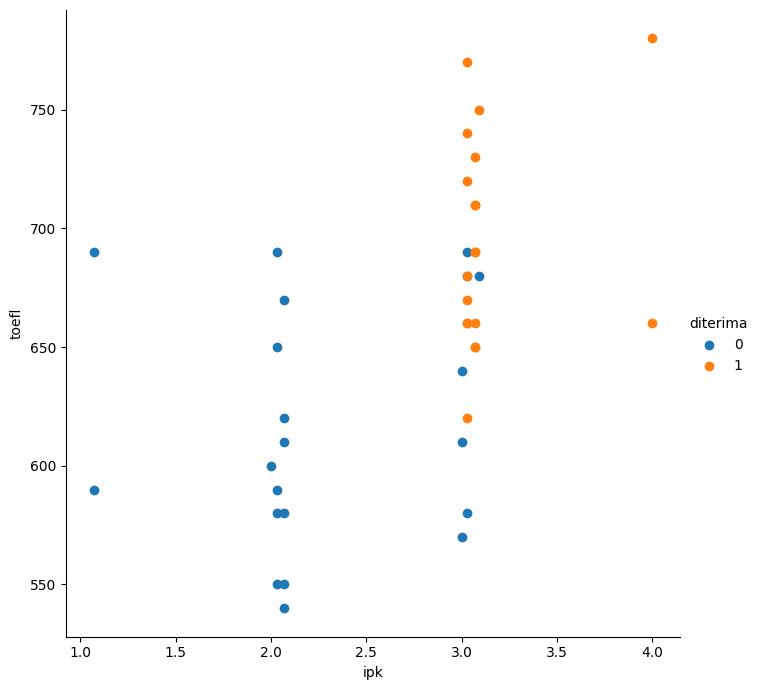

In [ ]:
sns.FacetGrid(data2,hue='diterima',height=7) \
  .map(plt.scatter, "ipk", "toefl") \
  .add_legend()

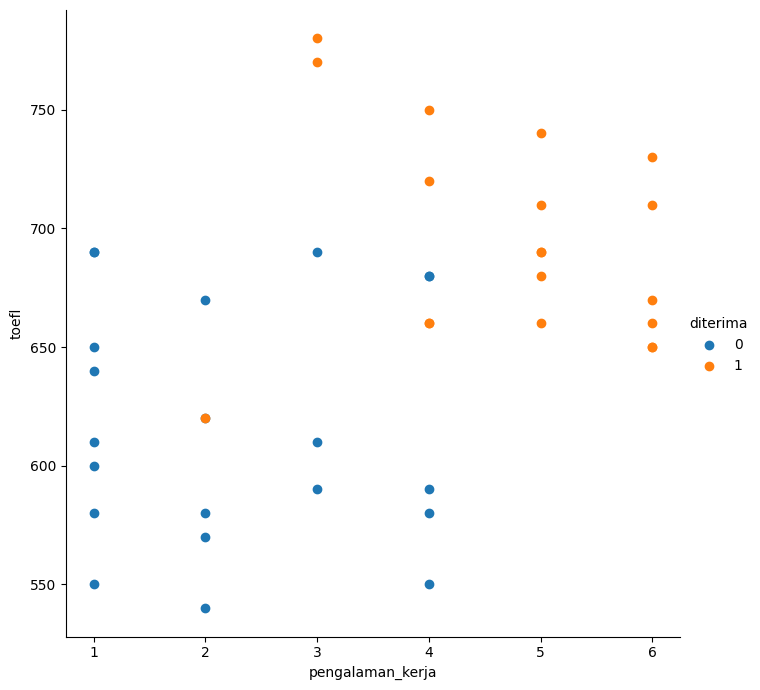

In [ ]:
sns.FacetGrid(data2,hue='diterima',height=7) \
  .map(plt.scatter, "pengalaman_kerja", "toefl") \
  .add_legend()

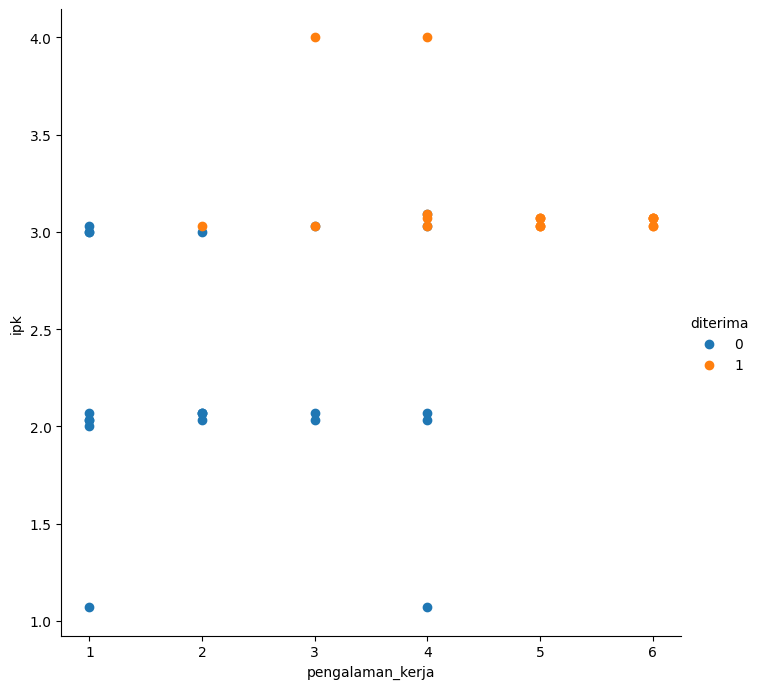

In [ ]:
sns.FacetGrid(data2,hue='diterima',height=7) \
  .map(plt.scatter, "pengalaman_kerja", "ipk") \
  .add_legend()

Analisa:

Ketiga visualisasi scatter plot di atas membandingkan variabel toefl, ipk, dan pengalaman kerja terhadap label diterima (0 = tidak diterima, 1 = diterima).

Plot IPK vs TOEFL
Tren yang terlihat: Pelamar dengan IPK di atas 3.0 dan TOEFL di atas 650 lebih sering diterima.
Pelamar dengan IPK rendah (sekitar 2.0 ke bawah) mayoritas tidak diterima, meskipun skor TOEFL-nya cukup tinggi.
Artinya, IPK dan TOEFL sama-sama penting, tetapi IPK cenderung lebih mendominasi keputusan penerimaan.

Plot Pengalaman Kerja vs TOEFL
Tren yang terlihat: Semakin banyak pengalaman kerja (di atas 3 tahun) dan TOEFL tinggi (lebih dari 680), peluang diterima meningkat.
Namun, ada pelamar dengan TOEFL tinggi tetapi pengalaman sedikit yang tetap tidak diterima.
Ini mengindikasikan bahwa pengalaman kerja juga berpengaruh, tapi tidak bisa berdiri sendiri tanpa dukungan dari aspek lain.

Plot Pengalaman Kerja vs IPK
Tren yang terlihat: Pelamar dengan IPK > 3.0 dan pengalaman kerja ≥ 3 tahun memiliki kemungkinan lebih besar untuk diterima.
Namun ada juga pelamar dengan IPK tinggi tetapi pengalaman minim yang tetap diterima.
Jadi, IPK tampaknya lebih kuat sebagai faktor penentu daripada pengalaman kerja.

Kesimpulan:
Kombinasi IPK tinggi + TOEFL tinggi + pengalaman kerja sangat meningkatkan peluang untuk diterima.
Di antara ketiganya, IPK tampaknya menjadi faktor paling dominan, diikuti oleh TOEFL dan kemudian pengalaman kerja.
Model machine learning seperti Logistic Regression cocok digunakan karena hubungan antara fitur dan label relatif linier.


c. Visualisasi data

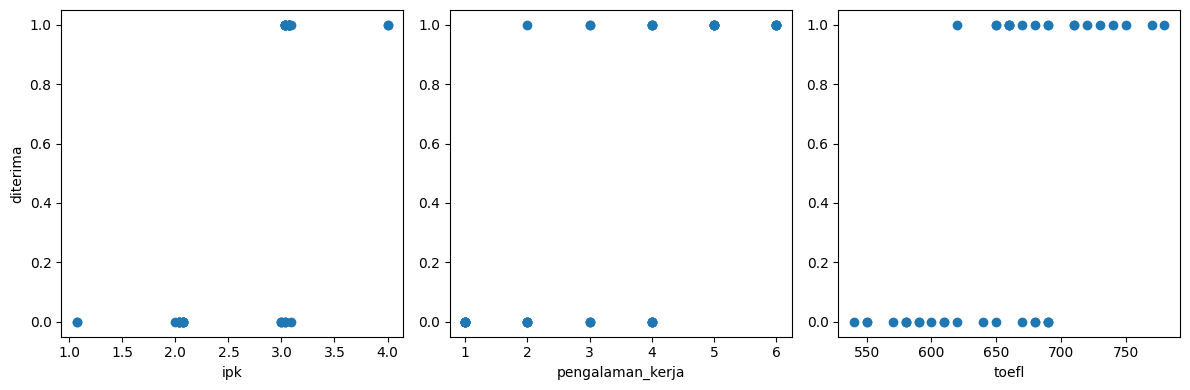

In [ ]:
# Setup subplot
plt.figure(figsize=(12, 4))

# Scatter plot untuk IPK vs diterima
plt.subplot(1, 3, 1)
plt.scatter(data2["ipk"], data2["diterima"])
plt.xlabel("ipk")
plt.ylabel("diterima")

# Scatter plot untuk pengalaman_kerja vs diterima
plt.subplot(1, 3, 2)
plt.scatter(data2["pengalaman_kerja"], data2["diterima"])
plt.xlabel("pengalaman_kerja")

# Scatter plot untuk toefl vs diterima
plt.subplot(1, 3, 3)
plt.scatter(data2["toefl"], data2["diterima"])
plt.xlabel("toefl")

plt.tight_layout()
plt.show()

d. Confusion matrix

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

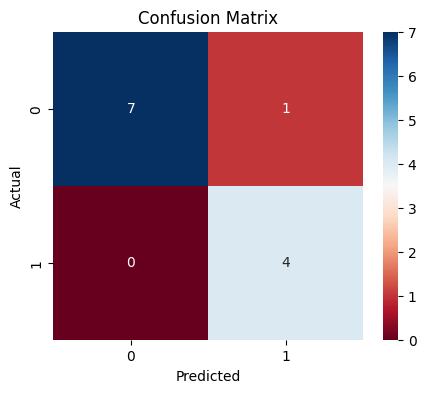

In [ ]:
X = data2[["toefl", "ipk", "pengalaman_kerja"]]
y = data2["diterima"]

# === Split Data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Latih Model Logistic Regression ===
model = LogisticRegression()
model.fit(X_train, y_train)

# === Prediksi ===
y_pred = model.predict(X_test)

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)

# === Plot dengan Heatmap ===
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

e. Membuat plot data

In [ ]:
data_index = [22, 20, 25, 4, 10, 15, 28, 11, 18, 29, 27, 35]
sample_data = data2.loc[data_index]
print("Data Sample:")
print(sample_data)

Data Sample:
    toefl   ipk  pengalaman_kerja  diterima  label
22    550  2.03                 4         0      0
20    620  3.03                 2         1      0
25    670  3.03                 6         1      0
4     680  3.09                 4         0      1
10    610  2.07                 3         0      1
15    610  3.00                 1         0      0
28    650  3.07                 6         1      0
11    690  3.07                 5         1      0
18    650  3.07                 6         1      0
29    660  3.03                 5         1      1
27    580  2.03                 2         0      0
35    650  2.03                 1         0      0


Analisa hasil:

Pelamar yang diterima cenderung memiliki toefl ≥ 650, ipk ≥ 3.0, dan pengalaman kerja ≥ 4 tahun. Pelamar dengan kombinasi nilai rendah cenderung tidak diterima.

f. Prediksi apakah pelamar baru akan diterima di tempat baru dan tidak diterima

In [ ]:
# === Data Pelamar Baru ===
pelamar_baru = pd.DataFrame({
    "toefl": [590, 740, 680, 610, 710],
    "ipk": [2.00, 3.07, 3.03, 2.03, 3.00],
    "pengalaman_kerja": [3, 4, 6, 1, 5]
})

# === Prediksi Diterima / Tidak ===
hasil_prediksi = model.predict(pelamar_baru)

# === Probabilitas Diterima ===
probabilitas = model.predict_proba(pelamar_baru)

# === Tampilkan Hasil ===
print("Hasil Prediksi untuk Setiap Pelamar Baru:\n")
for i in range(len(pelamar_baru)):
    status = "Diterima" if hasil_prediksi[i] == 1 else "Tidak Diterima"
    prob = probabilitas[i][1] * 100  # Probabilitas diterima
    print(f"Pelamar #{i+1}: {status} (Probabilitas diterima: {prob:.2f}%)")


Hasil Prediksi untuk Setiap Pelamar Baru:

Pelamar #1: Tidak Diterima (Probabilitas diterima: 7.35%)
Pelamar #2: Diterima (Probabilitas diterima: 92.28%)
Pelamar #3: Diterima (Probabilitas diterima: 94.99%)
Pelamar #4: Tidak Diterima (Probabilitas diterima: 2.07%)
Pelamar #5: Diterima (Probabilitas diterima: 93.51%)
